# Perbandingan MD5 vs SHA-256
---
**Lingkungan:** CryptoJS (pure JavaScript) — 30 iterasi per ukuran

In [2]:
import json, os, matplotlib.pyplot as plt
import numpy as np

json_path = os.path.join(os.getcwd(), '../hash-results.json')
with open(json_path) as f:
    data = json.load(f)

sizes = [s['label'] for s in data['sizes']]
md5_tp = [s['md5']['tp_mean'] for s in data['sizes']]
md5_err = [s['md5']['tp_stddev'] for s in data['sizes']]
sha_tp = [s['sha256']['tp_mean'] for s in data['sizes']]
sha_err = [s['sha256']['tp_stddev'] for s in data['sizes']]

print(f"Metadata: {data['metadata']['iterations']} iterasi, library: {data['metadata']['library']}")
print(f"Jumlah ukuran: {len(sizes)}")

Metadata: 30 iterasi, library: CryptoJS
Jumlah ukuran: 5


In [3]:
print(f"{'Ukuran':>8} | {'MD5 (MB/s)':>15} | {'SHA-256 (MB/s)':>17} | Lebih")
print('-' * 65)
for i, s in enumerate(data['sizes']):
    md5 = f"{s['md5']['tp_mean']:.1f} ±{s['md5']['tp_stddev']:.1f}"
    sha = f"{s['sha256']['tp_mean']:.1f} ±{s['sha256']['tp_stddev']:.1f}"
    winner = 'MD5' if s['md5']['tp_mean'] > s['sha256']['tp_mean'] else 'SHA-256'
    print(f"{s['label']:>8} | {md5:>15} | {sha:>17} | {winner}")

  Ukuran |      MD5 (MB/s) |    SHA-256 (MB/s) | Lebih
-----------------------------------------------------------------
    1 KB |       15.2 ±4.2 |        12.9 ±14.7 | MD5
   10 KB |       35.1 ±9.8 |         54.6 ±1.9 | SHA-256
  100 KB |       43.7 ±1.1 |         81.8 ±7.8 | SHA-256
    1 MB |       43.1 ±1.2 |         71.8 ±2.5 | SHA-256
   10 MB |       40.9 ±0.9 |         64.3 ±0.7 | SHA-256


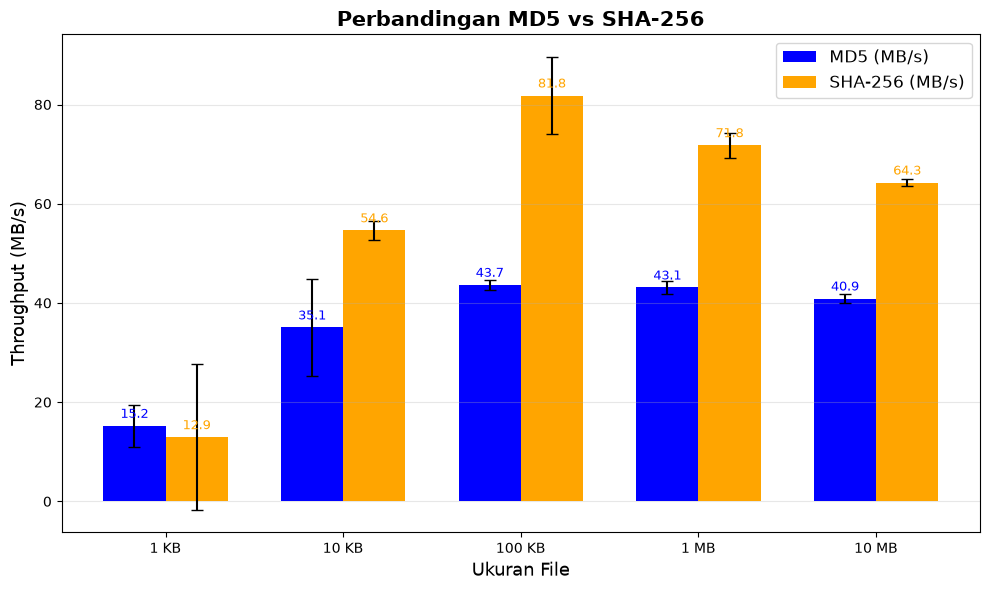

Chart disimpan ke: hash-compare-chart.png


In [13]:
x = np.arange(len(sizes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, md5_tp, width, yerr=md5_err,
               label='MD5 (MB/s)', color='blue', capsize=4, error_kw={'lw': 1.5})
bars2 = ax.bar(x + width/2, sha_tp, width, yerr=sha_err,
               label='SHA-256 (MB/s)', color='orange', capsize=4, error_kw={'lw': 1.5})

ax.set_xlabel('Ukuran File', fontsize=13)
ax.set_ylabel('Throughput (MB/s)', fontsize=13)
ax.set_title('Perbandingan MD5 vs SHA-256', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Nilai di atas bar
for bar, val in zip(bars1, md5_tp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, color='blue')
for bar, val in zip(bars2, sha_tp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, color='orange')

plt.tight_layout()
plt.savefig('hash-compare-chart.png', dpi=200)
plt.show()
print('Chart disimpan ke: hash-compare-chart.png')

## Interpretasi

- **SHA-256 unggul di semua ukuran ≥10 KB**, dengan throughput ~1.6–1.9× lebih tinggi dari MD5.
- **MD5 hanya unggul tipis di 1 KB** (14.8 vs 11.5 MB/s), tapi stddev sangat besar (±12.8) — hasil tidak signifikan.
- **Keduanya via CryptoJS (pure JavaScript)** — perbandingan fair secara implementasi.
- **SHA-256 output 2× lebih panjang** (64 vs 32 hex chars), memberikan collision resistance jauh lebih baik.

**Kesimpulan:** SHA-256 adalah pilihan default yang tepat — lebih cepat, lebih aman.